# Churn Prediction

This notebook builds the predictive baseline for **Beyond Churn**.

The question:

> **Who is most likely to churn without a retention treatment?**

Because the dataset comes from an experiment, I train the churn model only on the **control group**. That ensures the model is focused on just untreated churn risk.

The workflow is kept simple. I build a logistic regression baseline, compare it with CatBoost, choose a threshold using out-of-fold predictions, and evaluate on a held-out test set.

In [1]:
# imports
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import joblib

RANDOM_STATE = 42

## 1. Load and prepare the data

Notebook 01 contains the full data audit

In [2]:
dataset = openml.datasets.get_dataset(45580)

X_raw, y, _, _ = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

df = X_raw.copy()
df["y"] = y

treatment = df["t"].astype(int)
y = df["y"].astype(int)

X = df.drop(columns=["t", "y"]).copy()

# Constant feature identified in Notebook 01
if "FACTOR3" in X.columns:
    X = X.drop(columns=["FACTOR3"])

categorical_cols = X.select_dtypes(
    include=["object", "string", "str", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

X[categorical_cols] = X[categorical_cols].astype(str)

print("Rows:", len(X))
print("Features:", X.shape[1])
print("Overall churn rate:", round(y.mean(), 4))

Rows: 11896
Features: 177
Overall churn rate: 0.0343


## 2. Use the control group

The treatment itself can change churn, so I exclude treated customers from the predictive model.

This gives the model a cleaner interpretation, specifically **risk of churn without intervention**.

In [3]:
control_mask = treatment == 0

X_risk = X.loc[control_mask].copy()
y_risk = y.loc[control_mask].copy()

print("Control customers:", len(X_risk))
print("Control churners:", int(y_risk.sum()))
print("Control churn rate:", round(y_risk.mean(), 4))

Control customers: 2886
Control churners: 105
Control churn rate: 0.0364


## 3. Train / test split

The test set is set aside until the end. Model selection and threshold selection use only the training data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_risk,
    y_risk,
    test_size=0.25,
    stratify=y_risk,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Rows": [len(y_train), len(y_test)],
    "Churners": [int(y_train.sum()), int(y_test.sum())],
    "Churn rate": [y_train.mean(), y_test.mean()]
}, index=["Train", "Test"])

split_summary

,Rows,Churners,Churn rate
Train,2164,79,0.036506
Test,722,26,0.036011


## 4. Logistic regression baseline

Logistic regression is a good baseline before trying a more flexible or advanced tree-based model.

Numeric features are standardized and categorical features are one-hot encoded inside the pipeline.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_cols),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

logistic_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

logistic_oof = cross_val_predict(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("OOF ROC AUC:", round(roc_auc_score(y_train, logistic_oof), 3))
print(
    "OOF Average Precision:",
    round(average_precision_score(y_train, logistic_oof), 3)
)

OOF ROC AUC: 0.792
OOF Average Precision: 0.145


The out-of-fold scores give each training row a prediction from a model that did not train on that row. And this gives us a fairer estimate for model comparison.

## 5a. CatBoost challenger

CatBoost is great at handling categorical features. So, it is a good fit for this dataset.

I use a small hyperparameter search. The goal is to find a reasonable model, not try to exhaust every possible configuration.

In [6]:
# log loss to train predicted churn scores
# PRAUC can be more informative than accuracy for the imbalanced churn problem
catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="PRAUC",
    verbose=0,
    random_seed=RANDOM_STATE,
    thread_count=-1
)

catboost_params = {
    "iterations": [150, 300],
    "depth": [4, 6],
    "learning_rate": [0.03, 0.10],
    "l2_leaf_reg": [3, 10]
}

catboost_search = RandomizedSearchCV(
    estimator=catboost_model,
    param_distributions=catboost_params,
    n_iter=5,

    # Average precision summarizes precision-recall curve - good for comparing models when the positive class is rare
    scoring="average_precision",

    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=2
)

catboost_search.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

print("Best parameters:", catboost_search.best_params_)
print("Best CV Average Precision:", round(catboost_search.best_score_, 3))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.03; total time=   3.1s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.03; total time=   2.9s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.03; total time=   3.2s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.03; total time=   3.2s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.03; total time=   3.1s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.1; total time=   3.0s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.1; total time=   3.1s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.1; total time=   3.2s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.1; total time=   3.6s
[CV] END depth=4, iterations=150, l2_leaf_reg=3, learning_rate=0.1; total time=   3.3s
[CV] END depth=4, iterations=300, l2_leaf_reg=3, learning_rate=0.

### 5b. XGBoost challenger

XGBoost will be the second tree-based challenger.

Unlike CatBoost it does not use the raw categorical columns, so I reuse the preprocessing pipeline from logistic regression to one-hot encode them. A small randomized search is also used to find a fairly reasonable starting configuration.

In [7]:
# XGBoost -- predict churn probability using boosted decision trees
# note that average precision is used for model selection because churn is rare.

xgb_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

xgb_params = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.03, 0.10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params,
    n_iter=5,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=2
)

xgb_search.fit(
    X_train,
    y_train
)

print("Best parameters:", xgb_search.best_params_)
print("Best CV Average Precision:", round(xgb_search.best_score_, 3))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   0.7s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=150, model__subsample=1.0; total time=   0.5s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.1, model__max_depth=6, model__n_estimators=300, model__subsample=1.0; total time=   0.7s
[CV] END model__colsample_bytree=0.8, mo

### 5c. LightGBM challenger

LightGBM is the final tree-based challenger.

Like XGBoost, it uses the one-hot encoded features from our existing preprocessing pipeline. I use the same cross-validation setup and Average Precision scoring so the models can be compared fairly.

In [8]:
# LightGBM is another tree model
# Average precision is the selection metric for the rare churn class.

lgbm_model = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

lgbm_params = {
    "model__n_estimators": [150, 300],
    "model__learning_rate": [0.03, 0.10],
    "model__num_leaves": [15, 31],
    "model__max_depth": [-1, 6],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_params,
    n_iter=5,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    verbose=2
)

lgbm_search.fit(
    X_train,
    y_train
)

print("Best parameters:", lgbm_search.best_params_)
print(
    "Best CV Average Precision:",
    round(lgbm_search.best_score_, 3)
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=-1, model__n_estimators=300, model__num_leaves=15, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=-1, model__n_estimators=300, model__num_leaves=15, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=-1, model__n_estimators=300, model__num_leaves=15, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=-1, model__n_estimators=300, model__num_leaves=15, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=-1, model__n_estimators=300, model__num_leaves=15, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_

## 6. Compare the models with out-of-fold predictions

Now I compare all four models using out-of-fold predictions from the same training folds.

`Out-of-fold (OOF) predictions` are predictions made for each training row by a model that was not trained on that row. Using the same cross-validation folds for every model gives a fair comparison and helps us avoid evaluating the models on data they already saw during training.

Average Precision is the main selection metric because churn is rare. ROC AUC is included as a secondary ranking metric.

In [9]:
# Get best parameters from each randomized search
best_catboost_params = catboost_search.best_params_
best_xgb_params = xgb_search.best_params_
best_lgbm_params = lgbm_search.best_params_


# CatBoost OOF predictions
catboost_oof = np.zeros(len(X_train))

for train_fold_idx, valid_fold_idx in cv.split(X_train, y_train):
    fold_model = CatBoostClassifier(
        **best_catboost_params,
        loss_function="Logloss",
        eval_metric="PRAUC",
        verbose=0,
        random_seed=RANDOM_STATE,
        thread_count=-1
    )

    fold_model.fit(
        X_train.iloc[train_fold_idx],
        y_train.iloc[train_fold_idx],
        cat_features=categorical_cols
    )

    catboost_oof[valid_fold_idx] = fold_model.predict_proba(
        X_train.iloc[valid_fold_idx]
    )[:, 1]


# XGBoost OOF predictions
xgb_best_model = clone(xgb_search.best_estimator_)

xgb_oof = cross_val_predict(
    xgb_best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]


# LightGBM OOF predictions
lgbm_best_model = clone(lgbm_search.best_estimator_)

lgbm_oof = cross_val_predict(
    lgbm_best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]


# Compare all models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "CatBoost",
        "XGBoost",
        "LightGBM"
    ],
    "ROC AUC": [
        roc_auc_score(y_train, logistic_oof),
        roc_auc_score(y_train, catboost_oof),
        roc_auc_score(y_train, xgb_oof),
        roc_auc_score(y_train, lgbm_oof)
    ],
    "Average Precision": [
        average_precision_score(y_train, logistic_oof),
        average_precision_score(y_train, catboost_oof),
        average_precision_score(y_train, xgb_oof),
        average_precision_score(y_train, lgbm_oof)
    ]
})

model_comparison = model_comparison.sort_values(
    "Average Precision",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,ROC AUC,Average Precision
0,LightGBM,0.846596,0.160944
1,Logistic Regression,0.791986,0.144654
2,CatBoost,0.824236,0.143014
3,XGBoost,0.809814,0.142504


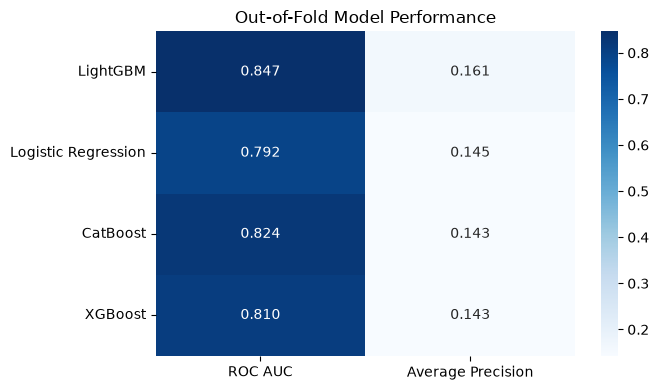

In [10]:
# make heatmap
comparison_heatmap = (
    model_comparison
    .set_index("Model")[["ROC AUC", "Average Precision"]]
)

plt.figure(figsize=(7, 4))

sns.heatmap(
    comparison_heatmap,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Out-of-Fold Model Performance")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

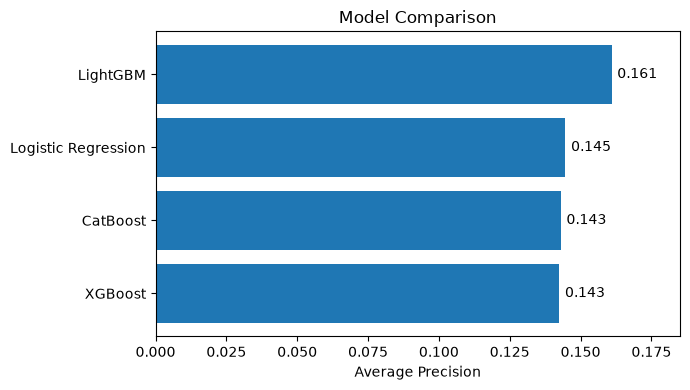

In [11]:
# average precision chart
ap_comparison = model_comparison.sort_values(
    "Average Precision",
    ascending=True
)

plt.figure(figsize=(7, 4))

plt.barh(
    ap_comparison["Model"],
    ap_comparison["Average Precision"]
)

plt.xlabel("Average Precision")
plt.title("Model Comparison")

for i, value in enumerate(ap_comparison["Average Precision"]):
    plt.text(
        value + 0.002,
        i,
        f"{value:.3f}",
        va="center"
    )

plt.xlim(
    0,
    ap_comparison["Average Precision"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Model selection

LightGBM performed best across both evaluation metrics. It had the highest ROC AUC (0.847) and Average Precision (0.161).

Because Average Precision is the primary selection metric for this imbalanced churn problem, LightGBM is selected as the final churn-risk model. The remaining workflow uses LightGBM for threshold selection and held-out test evaluation.

## 7. Select classification threshold

The LightGBM model ranks customers by churn risk. But we could also use a threshold if we want a simple high-risk / low-risk classification. 

In this section, I will be using `F2` as a primary threshold metric. F2 is used because it will give more weight to recall than precision. But instead of choosing the threshold that maximizes F2 alone, I will also require a minimum recall level of 0.25. This means it needs to capture at least 25% of actual churners. And then I will select the threshold with the highest F2 among that recall constraint.

The threshold is selected using out-of-fold training predictions so the test set remains untouched.

In [12]:
# test a range of possible churn risk thresholds
threshold_rows = []

for threshold in np.arange(0.005, 0.301, 0.005):
    predictions = (lgbm_oof >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_train,
            predictions,
            beta=2,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_rows)

# Require the model to capture at least 25% of churners
MIN_RECALL = 0.25

eligible_thresholds = threshold_results[
    threshold_results["Recall"] >= MIN_RECALL
].copy()

# Among eligible thresholds choose the one with the highest F2
best_threshold_row = eligible_thresholds.loc[
    eligible_thresholds["F2"].idxmax()
]

selected_threshold = float(
    best_threshold_row["Threshold"]
)

print("Minimum recall:", MIN_RECALL)
print("Selected threshold:", round(selected_threshold, 3))

best_threshold_row.to_frame().T

Minimum recall: 0.25
Selected threshold: 0.005


,Threshold,Precision,Recall,F2
0,0.005,0.151899,0.303797,0.253165


**Note:** The selected threshold is low in absolute terms. But the LightGBM scores are being used primarily for ranking rather than as calibrated churn probabilities. So, at this threshold, the model captures about 30% of churners while maintaining roughly 15% precision.

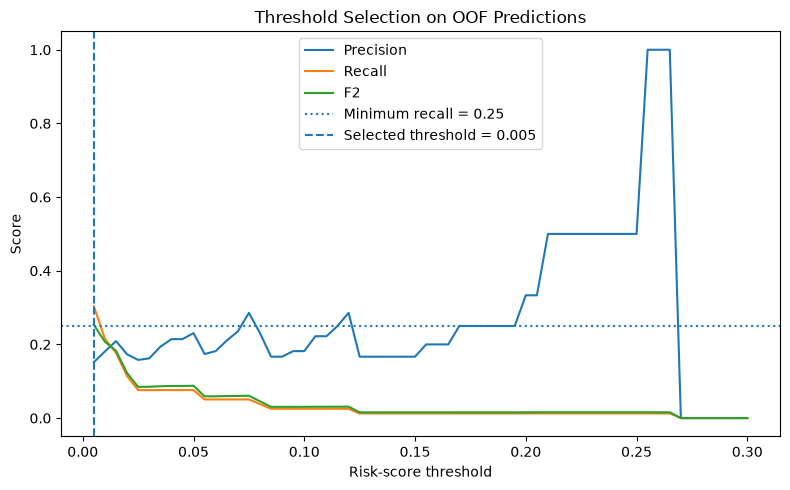

In [13]:
# plot
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F2"],
    label="F2"
)

# Minimum recall requirement.
plt.axhline(
    MIN_RECALL,
    linestyle=":",
    label=f"Minimum recall = {MIN_RECALL:.2f}"
)

# Final selected threshold.
plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.3f}"
)

plt.xlabel("Risk-score threshold")
plt.ylabel("Score")
plt.title("Threshold Selection on OOF Predictions")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final test evaluation

Now I fit LightGBM on the full training set and evaluate it once on the held-out test set. The classification threshold was chosen in the section above using the out-of-fold training predictions

In [14]:
# refit the LightGBM model on full training data
final_model = clone(lgbm_search.best_estimator_)

final_model.fit(
    X_train,
    y_train
)

# get test set churn scores and classifications
test_scores = final_model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_scores >= selected_threshold
).astype(int)

# evaluate ranking quality and performance
test_metrics = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Average Precision",
        "Precision",
        "Recall",
        "F1",
        "F2"
    ],
    "Result": [
        roc_auc_score(y_test, test_scores),
        average_precision_score(y_test, test_scores),
        precision_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        fbeta_score(
            y_test,
            test_predictions,
            beta=2,
            zero_division=0
        )
    ]
})

test_metrics

,Metric,Result
0,ROC AUC,0.841346
1,Average Precision,0.187324
2,Precision,0.108434
3,Recall,0.346154
4,F1,0.165138
5,F2,0.240642


In [15]:
# we can also add a classification report
print(
    classification_report(
        y_test,
        test_predictions,
        digits=3
    )
)

              precision    recall  f1-score   support

           0      0.973     0.894     0.932       696
           1      0.108     0.346     0.165        26

    accuracy                          0.874       722
   macro avg      0.541     0.620     0.548       722
weighted avg      0.942     0.874     0.904       722



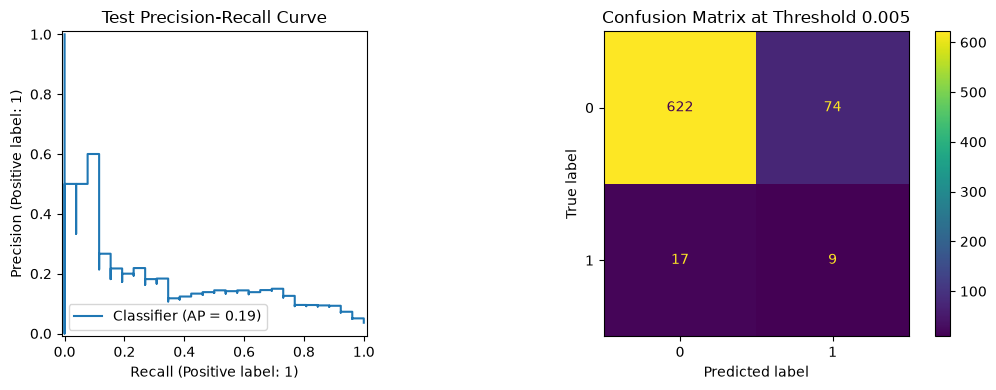

In [16]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)

# this shows precision and recall across all thresholds
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_scores,
    ax=axes[0]
)

axes[0].set_title(
    "Test Precision-Recall Curve"
)

# and this shows final classifications at selected threshold
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    ax=axes[1]
)

axes[1].set_title(
    f"Confusion Matrix at Threshold {selected_threshold:.3f}"
)

plt.tight_layout()
plt.show()

## 9. Feature importance

Recall that the predictors are anonymized. So, feature importance will help show which variables influence the model most, but not what those variables mean in business terms.

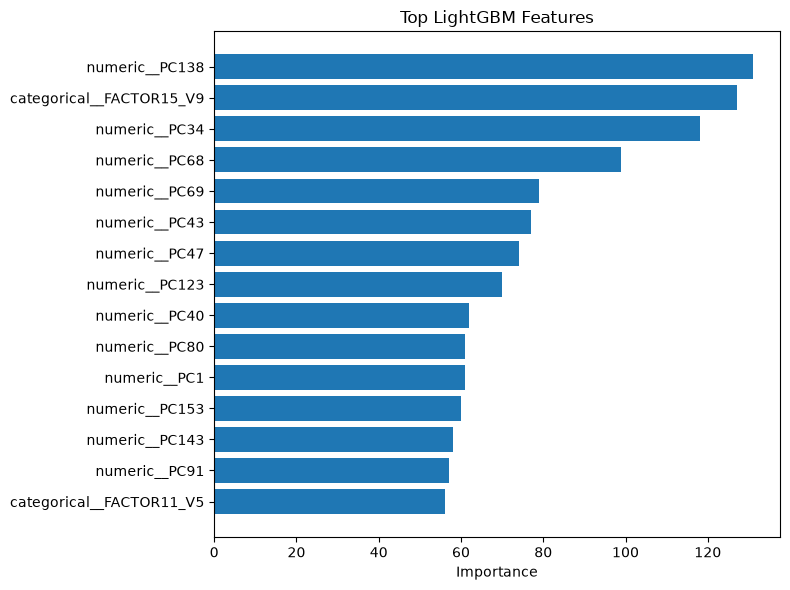

,Feature,Importance
137,numeric__PC138,131
299,categorical__FACTOR15_V9,127
33,numeric__PC34,118
67,numeric__PC68,99
68,numeric__PC69,79
42,numeric__PC43,77
46,numeric__PC47,74
122,numeric__PC123,70
39,numeric__PC40,62
79,numeric__PC80,61


In [17]:
# we need to get the fitted preprocessing and LightGBM steps from the pipeline I created
fitted_preprocessor = final_model.named_steps["preprocess"]
fitted_lgbm = final_model.named_steps["model"]

# Get feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Now run LightGBM feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_lgbm.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top LightGBM Features")
plt.tight_layout()
plt.show()

feature_importance

## 10. Save the model

The final LightGBM pipeline and small metadata file will be saved

In [18]:
artifact_dir = Path("../artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lightgbm_churn_model.joblib"
metadata_path = artifact_dir / "lightgbm_churn_metadata.json"

# Save full preprocessing + LightGBM pipeline.
joblib.dump(
    final_model,
    model_path
)

# Save the main model settings and final test results.
metadata = {
    "model": "LightGBM",
    "selected_threshold": selected_threshold,
    "minimum_recall": MIN_RECALL,
    "feature_names": X_train.columns.tolist(),
    "categorical_features": categorical_cols,
    "numeric_features": numeric_cols,
    "best_params": lgbm_search.best_params_,
    "test_roc_auc": roc_auc_score(
        y_test,
        test_scores
    ),
    "test_average_precision": average_precision_score(
        y_test,
        test_scores
    ),
    "test_precision": precision_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "test_recall": recall_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "test_f1": f1_score(
        y_test,
        test_predictions,
        zero_division=0
    ),
    "test_f2": fbeta_score(
        y_test,
        test_predictions,
        beta=2,
        zero_division=0
    )
}

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=2
    )

print("Saved:", model_path.resolve())
print("Saved:", metadata_path.resolve())

Saved: C:\dev\beyond-churn\artifacts\lightgbm_churn_model.joblib
Saved: C:\dev\beyond-churn\artifacts\lightgbm_churn_metadata.json


## Takeaways

- The churn model is trained only on untreated customers, so it represents untreated churn risk.
- Logistic Regression, CatBoost, XGBoost, and LightGBM were compared using the same cross-validation setup.
- LightGBM performed best and was selected as the final model.
- Out-of-fold predictions were used for model comparison and threshold selection.
- The selected threshold requires at least 25% recall and then chooses the highest F2 score.
- The hold-out test set was used at the end for final performance evaluation.
- Feature importance shows the model relies on a mix of numeric and categorical predictors, with PC138 and FACTOR15_V9 having the strongest signals.
- Note that the LightGBM scores are good for ranking churn risk, but they are not treated as calibrated probabilities.

The next notebook compares this churn-risk ranking with causal treatment-response models.